In [1]:
!pip install seaborn yfinance

In [2]:
# ============================================================
# STEP 1: Imports, Stock Universe, and Data Download
# ============================================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# ---- 24-stock universe across 6 sectors (NSE tickers) ----
sector_map = {
    # IT (5)
    'TCS.NS': 'IT', 'INFY.NS': 'IT', 'HCLTECH.NS': 'IT', 'WIPRO.NS': 'IT', 'TECHM.NS': 'IT',
    # Banking / Financial Services (5)
    'HDFCBANK.NS': 'Banking', 'ICICIBANK.NS': 'Banking', 'SBIN.NS': 'Banking',
    'KOTAKBANK.NS': 'Banking', 'AXISBANK.NS': 'Banking',
    # FMCG (5)
    'HINDUNILVR.NS': 'FMCG', 'ITC.NS': 'FMCG', 'NESTLEIND.NS': 'FMCG',
    'BRITANNIA.NS': 'FMCG', 'DABUR.NS': 'FMCG',
    # Auto (3)
    'MARUTI.NS': 'Auto', 'M&M.NS': 'Auto', 'BAJAJ-AUTO.NS': 'Auto',
    # Pharma (3)
    'SUNPHARMA.NS': 'Pharma', 'DRREDDY.NS': 'Pharma', 'CIPLA.NS': 'Pharma',
    # Energy (3)
    'RELIANCE.NS': 'Energy', 'ONGC.NS': 'Energy', 'NTPC.NS': 'Energy',
}

tickers = list(sector_map.keys())
print(f"Total stocks: {len(tickers)}")
print(f"Sectors: {sorted(set(sector_map.values()))}")

# ---- Date range: 10 years ----
end_date = datetime.today()
start_date = end_date - timedelta(days=10*365)

print(f"\nDownloading data from {start_date.date()} to {end_date.date()} ...")

# ---- Download adjusted close prices ----
raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True, progress=True)
prices = raw_data['Close']  # with auto_adjust=True, 'Close' is already adjusted

# ---- Basic cleaning ----
print(f"\nRaw shape: {prices.shape}")
missing_pct = prices.isna().mean().sort_values(ascending=False)
print("\nMissing % by stock (top 5):")
print(missing_pct.head())

# Drop any stock with >5% missing data, forward-fill the rest
good_tickers = missing_pct[missing_pct <= 0.05].index.tolist()
prices = prices[good_tickers].ffill().dropna()

print(f"\nFinal cleaned shape: {prices.shape}")
print(f"Stocks retained: {len(good_tickers)} / {len(tickers)}")
print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")

prices.head()

Total stocks: 24
Sectors: ['Auto', 'Banking', 'Energy', 'FMCG', 'IT', 'Pharma']



[*********************100%***********************]  24 of 24 completed


Raw shape: (2473, 24)

Missing % by stock (top 5):
Ticker
AXISBANK.NS     0.0004
CIPLA.NS        0.0004
HINDUNILVR.NS   0.0004
BAJAJ-AUTO.NS   0.0000
DABUR.NS        0.0000
dtype: float64

Final cleaned shape: (2473, 24)
Stocks retained: 24 / 24
Date range: 2016-09-15 to 2026-09-11


Ticker,AXISBANK.NS,CIPLA.NS,HINDUNILVR.NS,BAJAJ-AUTO.NS,DABUR.NS,DRREDDY.NS,HCLTECH.NS,BRITANNIA.NS,HDFCBANK.NS,ICICIBANK.NS,...,MARUTI.NS,NESTLEIND.NS,NTPC.NS,ONGC.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TECHM.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2016-09-15,579.4305,545.0448,778.1777,2272.8662,263.2883,586.6725,291.2532,1528.0847,291.7581,232.4898,...,4962.9663,278.3323,88.6602,98.2643,232.2926,229.9535,721.5483,914.8390,333.4524,80.5854
2016-09-16,592.6677,552.6330,776.2196,2311.5129,262.3030,588.6721,294.0013,1503.8107,295.9192,229.6976,...,5073.0137,282.9966,88.4579,98.9760,234.5937,228.4264,719.2084,928.5008,335.2899,80.7454
2016-09-19,584.9420,556.5900,776.4326,2283.7976,263.7363,590.0175,295.0107,1476.1617,294.1635,233.3490,...,4998.9214,279.9246,89.6717,100.4984,236.0878,229.6391,718.0154,948.0602,336.2266,80.8381
2016-09-20,583.5640,561.2919,768.7272,2238.1345,260.9144,590.1015,296.1325,1475.6858,293.7759,233.7786,...,5019.8115,280.0350,88.6602,101.9220,234.2993,228.5611,714.5745,946.1144,333.0560,81.0233
2016-09-21,589.4199,559.8952,777.3691,2250.3062,259.4810,589.2045,296.3380,1470.3206,294.8133,231.8884,...,5007.4316,278.8469,89.0070,100.9729,233.8739,225.5969,714.6662,948.8269,332.2994,81.4949


Working with 24 stocks
=== Individual Stock Stats (10Y Annualized) ===
                Sector  Ann_Return_%  Ann_Volatility_%  Return/Risk
Ticker                                                             
ICICIBANK.NS   Banking       22.4100           29.1900       0.7700
RELIANCE.NS     Energy       20.8600           27.0300       0.7700
M&M.NS            Auto       20.7400           30.5400       0.6800
SBIN.NS        Banking       19.9400           31.7600       0.6300
BAJAJ-AUTO.NS     Auto       19.9100           25.3500       0.7900
TECHM.NS            IT       19.8900           29.1800       0.6800
NESTLEIND.NS      FMCG       18.7300           21.9000       0.8600
HCLTECH.NS          IT       18.0000           26.5100       0.6800
NTPC.NS         Energy       16.8200           25.7100       0.6500
BRITANNIA.NS      FMCG       14.6300           22.9200       0.6400
ONGC.NS         Energy       14.2400           33.0000       0.4300
INFY.NS             IT       13.5200         

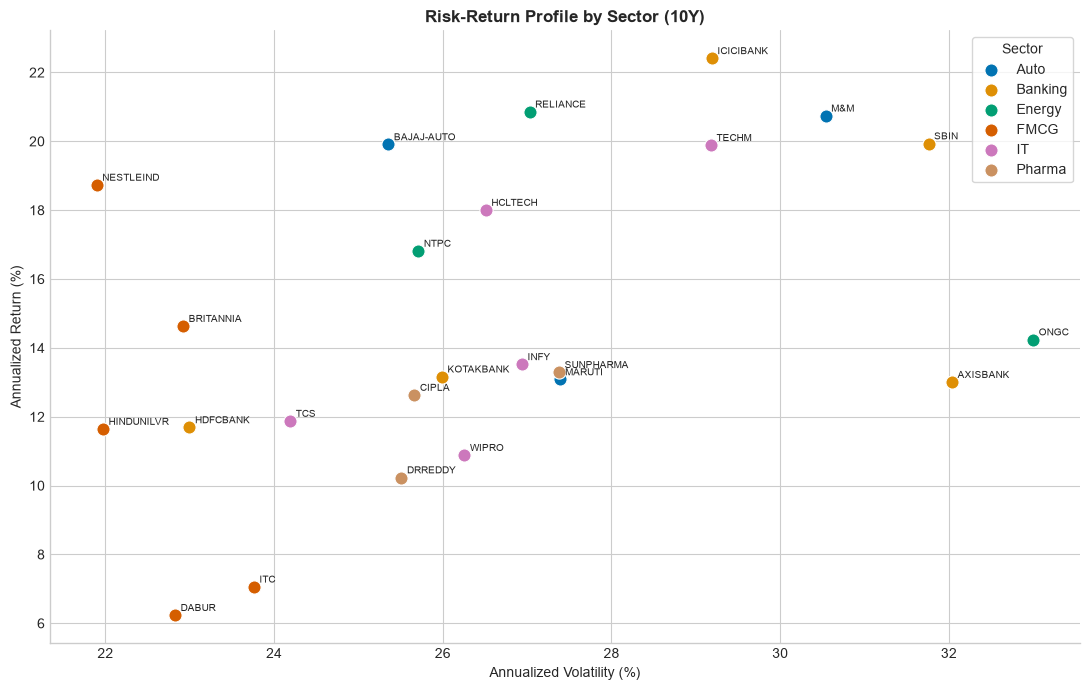

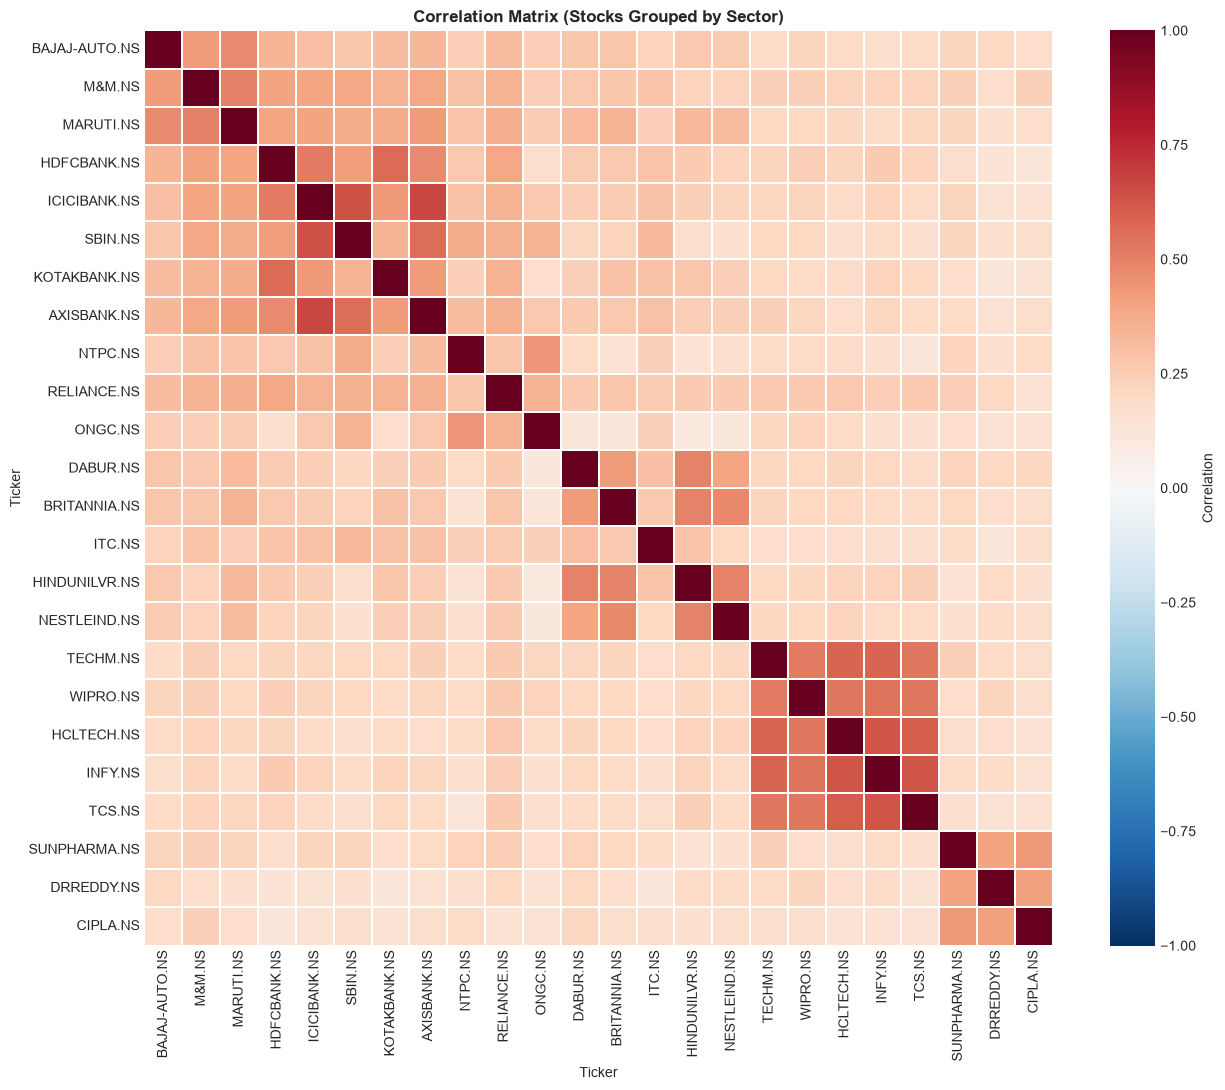


Daily returns shape: (2472, 24)


In [9]:
# ============================================================
# STEP 2: Daily Returns, Annualized Stats, Sector Analysis
# ============================================================

# ---- Update sector_map and tickers to match what actually downloaded ----
final_tickers = prices.columns.tolist()
sector_map = {t: s for t, s in sector_map.items() if t in final_tickers}
print(f"Working with {len(final_tickers)} stocks")

# ---- Daily simple returns ----
daily_returns = prices.pct_change().dropna()

# ---- Annualized return & volatility per stock (252 trading days) ----
TRADING_DAYS = 252
ann_return = daily_returns.mean() * TRADING_DAYS
ann_vol = daily_returns.std() * np.sqrt(TRADING_DAYS)

stock_stats = pd.DataFrame({
    'Sector': [sector_map[t] for t in ann_return.index],
    'Ann_Return_%': ann_return * 100,
    'Ann_Volatility_%': ann_vol * 100,
    'Return/Risk': ann_return / ann_vol
}).sort_values('Ann_Return_%', ascending=False)

print("=== Individual Stock Stats (10Y Annualized) ===")
print(stock_stats.round(2))

# ---- Covariance & correlation matrix (annualized) ----
cov_matrix = daily_returns.cov() * TRADING_DAYS
corr_matrix = daily_returns.corr()

# ============================================================
# SECTOR-WISE ANALYSIS
# ============================================================
sector_series = pd.Series(sector_map)

sector_stats = stock_stats.groupby('Sector').agg(
    Avg_Return_pct=('Ann_Return_%', 'mean'),
    Avg_Volatility_pct=('Ann_Volatility_%', 'mean'),
    Num_Stocks=('Ann_Return_%', 'count')
).round(2).sort_values('Avg_Return_pct', ascending=False)

print("\n=== Sector-Wise Summary ===")
print(sector_stats)

# ---- Plot 1: Risk-Return scatter colored by sector ----
fig, ax = plt.subplots(figsize=(11, 7))
sectors_unique = sorted(sector_series.unique())
palette = dict(zip(sectors_unique, sns.color_palette("colorblind", len(sectors_unique))))

for sector in sectors_unique:
    stocks_in_sector = stock_stats[stock_stats['Sector'] == sector]
    ax.scatter(stocks_in_sector['Ann_Volatility_%'], stocks_in_sector['Ann_Return_%'],
               label=sector, s=90, color=palette[sector], edgecolor='white', linewidth=0.8)
    for name, row in stocks_in_sector.iterrows():
        ax.annotate(name.replace('.NS',''), (row['Ann_Volatility_%'], row['Ann_Return_%']),
                    fontsize=7.5, xytext=(4,3), textcoords='offset points')

ax.set_xlabel('Annualized Volatility (%)')
ax.set_ylabel('Annualized Return (%)')
ax.set_title('Risk-Return Profile by Sector (10Y)', fontweight='bold')
ax.legend(title='Sector', loc='best', frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('sector_risk_return.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot 2: Correlation heatmap, stocks ordered by sector ----
order = sector_series.sort_values().index.tolist()
order = [t for t in order if t in corr_matrix.columns]

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr_matrix.loc[order, order], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.3, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix (Stocks Grouped by Sector)', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDaily returns shape: {daily_returns.shape}")

In [11]:
# ============================================================
# STEP 2.5: Train/Test Split (to avoid look-ahead bias)
# ============================================================
split_date = daily_returns.index[int(len(daily_returns) * 0.7)]  # ~7y train / 3y test

train_returns = daily_returns.loc[:split_date]
test_returns  = daily_returns.loc[split_date:]
train_prices  = prices.loc[:split_date]
test_prices   = prices.loc[split_date:]

print(f"Train: {train_returns.index.min().date()} to {train_returns.index.max().date()} ({len(train_returns)} days)")
print(f"Test:  {test_returns.index.min().date()} to {test_returns.index.max().date()} ({len(test_returns)} days)")

ann_return_train = train_returns.mean() * TRADING_DAYS
ann_vol_train = train_returns.std() * np.sqrt(TRADING_DAYS)
cov_matrix_train = train_returns.cov() * TRADING_DAYS

Train: 2016-09-16 to 2023-09-14 (1731 days)
Test:  2023-09-14 to 2026-09-11 (742 days)


=== Minimum Variance Portfolio (MVP) — trained on in-sample period ===
Expected Annual Return: 17.18%
Annual Volatility:      13.71%
Sharpe Ratio:           0.78

=== Maximum Sharpe Portfolio (MSP) — trained on in-sample period ===
Expected Annual Return: 23.61%
Annual Volatility:      16.71%
Sharpe Ratio:           1.02

=== Portfolio Weights (sorted by MSP allocation) ===
                Sector  MVP_Weight_%  MSP_Weight_%
NESTLEIND.NS      FMCG       11.6200       28.3100
RELIANCE.NS     Energy        0.0000       22.6100
TCS.NS              IT       12.2300       13.2400
ICICIBANK.NS   Banking        0.0000       11.6300
HCLTECH.NS          IT        0.8600       11.6300
NTPC.NS         Energy       10.7800        3.6800
CIPLA.NS        Pharma        8.8200        3.4900
INFY.NS             IT        0.3700        2.5200
HINDUNILVR.NS     FMCG        6.1200        1.7700
TECHM.NS            IT        0.0000        1.1100
HDFCBANK.NS    Banking        9.5200        0.0000
ITC.NS     

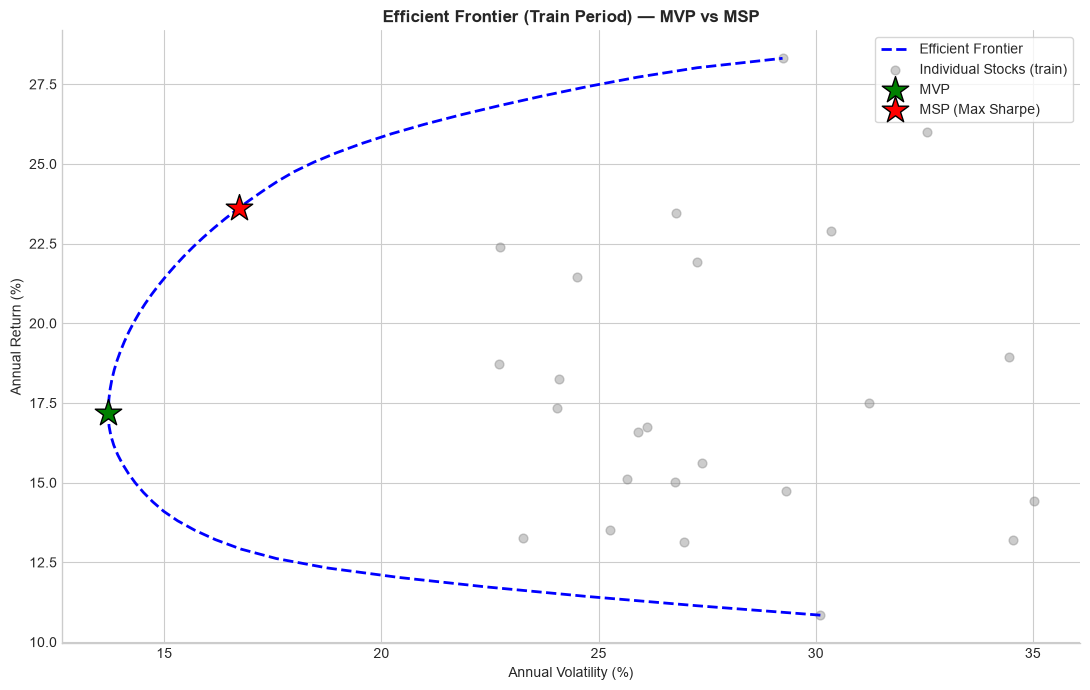

In [12]:
# ============================================================
# STEP 3: Portfolio Optimization — Minimum Variance & Max Sharpe
# ============================================================
from scipy.optimize import minimize
import os

os.makedirs('reports/figures', exist_ok=True)  # for when you move this into the repo

RISK_FREE_RATE = 0.065  # approx. India 10Y G-Sec yield — adjust if you want a different anchor
n_assets = len(final_tickers)

def portfolio_performance(weights, mean_returns, cov_matrix):
    ret = np.dot(weights, mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return ret, vol

def neg_sharpe_ratio(weights, mean_returns, cov_matrix, rf=RISK_FREE_RATE):
    ret, vol = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(ret - rf) / vol

def portfolio_volatility(weights, mean_returns, cov_matrix):
    return portfolio_performance(weights, mean_returns, cov_matrix)[1]

# ---- Long-only, fully invested constraints ----
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0, 1) for _ in range(n_assets))
init_guess = np.array([1/n_assets] * n_assets)

# ---- Use TRAIN-ONLY stats for optimization (avoids look-ahead bias) ----
mean_ret_arr = ann_return_train.values
cov_arr = cov_matrix_train.values

# ---- Minimum Variance Portfolio (MVP) ----
mvp_res = minimize(portfolio_volatility, init_guess, args=(mean_ret_arr, cov_arr),
                    method='SLSQP', bounds=bounds, constraints=constraints)
mvp_weights = mvp_res.x
mvp_ret, mvp_vol = portfolio_performance(mvp_weights, mean_ret_arr, cov_arr)
mvp_sharpe = (mvp_ret - RISK_FREE_RATE) / mvp_vol

# ---- Maximum Sharpe Portfolio (MSP) ----
msp_res = minimize(neg_sharpe_ratio, init_guess, args=(mean_ret_arr, cov_arr, RISK_FREE_RATE),
                    method='SLSQP', bounds=bounds, constraints=constraints)
msp_weights = msp_res.x
msp_ret, msp_vol = portfolio_performance(msp_weights, mean_ret_arr, cov_arr)
msp_sharpe = (msp_ret - RISK_FREE_RATE) / msp_vol

print("=== Minimum Variance Portfolio (MVP) — trained on in-sample period ===")
print(f"Expected Annual Return: {mvp_ret*100:.2f}%")
print(f"Annual Volatility:      {mvp_vol*100:.2f}%")
print(f"Sharpe Ratio:           {mvp_sharpe:.2f}")

print("\n=== Maximum Sharpe Portfolio (MSP) — trained on in-sample period ===")
print(f"Expected Annual Return: {msp_ret*100:.2f}%")
print(f"Annual Volatility:      {msp_vol*100:.2f}%")
print(f"Sharpe Ratio:           {msp_sharpe:.2f}")

# ---- Weight allocation table ----
weights_df = pd.DataFrame({
    'Sector': [sector_map[t] for t in final_tickers],
    'MVP_Weight_%': mvp_weights * 100,
    'MSP_Weight_%': msp_weights * 100
}, index=final_tickers).sort_values('MSP_Weight_%', ascending=False)

print("\n=== Portfolio Weights (sorted by MSP allocation) ===")
print(weights_df.round(2))

# ---- Efficient Frontier (built from train-only stats) ----
target_returns = np.linspace(ann_return_train.min(), ann_return_train.max(), 60)
frontier_vols = []
for target in target_returns:
    cons = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, t=target: portfolio_performance(w, mean_ret_arr, cov_arr)[0] - t}
    )
    res = minimize(portfolio_volatility, init_guess, args=(mean_ret_arr, cov_arr),
                    method='SLSQP', bounds=bounds, constraints=cons)
    frontier_vols.append(res.fun if res.success else np.nan)

frontier_df = pd.DataFrame({'Return': target_returns, 'Volatility': frontier_vols}).dropna()

# ---- Plot ----
fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(frontier_df['Volatility']*100, frontier_df['Return']*100, 'b--', linewidth=2, label='Efficient Frontier')
ax.scatter(ann_vol_train*100, ann_return_train*100, c='gray', alpha=0.4, s=40, label='Individual Stocks (train)')
ax.scatter(mvp_vol*100, mvp_ret*100, marker='*', s=400, color='green', edgecolor='black', label='MVP', zorder=5)
ax.scatter(msp_vol*100, msp_ret*100, marker='*', s=400, color='red', edgecolor='black', label='MSP (Max Sharpe)', zorder=5)
ax.set_xlabel('Annual Volatility (%)')
ax.set_ylabel('Annual Return (%)')
ax.set_title('Efficient Frontier (Train Period) — MVP vs MSP', fontweight='bold')
ax.legend(loc='best', frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('reports/figures/03_efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

=== Constrained MSP (max 15% per stock) ===
Expected Annual Return: 22.54%
Annual Volatility:      16.00%
Sharpe Ratio:           1.00
Number of active positions (>1%): 11

=== Weight Comparison ===
                Sector  MVP_Weight_%  MSP_Weight_%  MSP_Constrained_%
AXISBANK.NS    Banking        0.0000        0.0000            15.0000
M&M.NS            Auto        0.0000        0.0000            15.0000
ONGC.NS         Energy        1.2700        0.0000            14.5800
TECHM.NS            IT        0.0000        1.1100            13.4800
CIPLA.NS        Pharma        8.8200        3.4900            13.1000
TCS.NS              IT       12.2300       13.2400             8.9800
DRREDDY.NS      Pharma        9.1300        0.0000             6.1500
RELIANCE.NS     Energy        0.0000       22.6100             5.3000
INFY.NS             IT        0.3700        2.5200             3.3000
HDFCBANK.NS    Banking        9.5200        0.0000             3.1400
SUNPHARMA.NS    Pharma        0

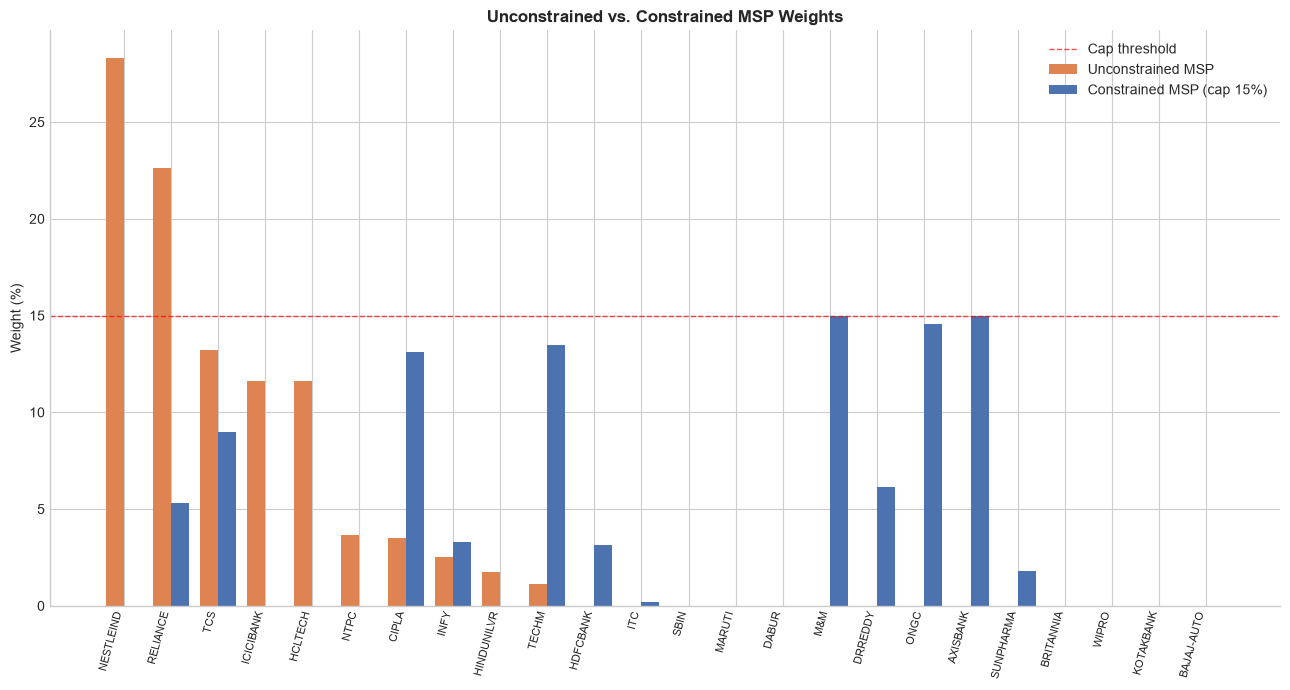

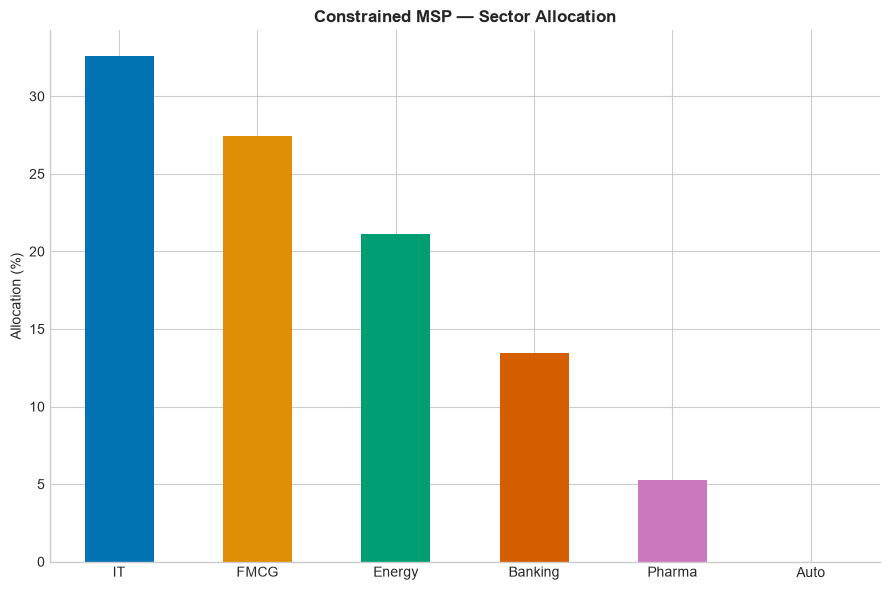

In [13]:
# ============================================================
# STEP 4: Constrained Maximum Sharpe Portfolio (diversification cap)
# ============================================================

MAX_WEIGHT = 0.15  # no single stock > 15% — forces diversification across sectors

constrained_bounds = tuple((0, MAX_WEIGHT) for _ in range(n_assets))

msp_constrained_res = minimize(
    neg_sharpe_ratio, init_guess, args=(mean_ret_arr, cov_arr, RISK_FREE_RATE),
    method='SLSQP', bounds=constrained_bounds, constraints=constraints
)
msp_c_weights = msp_constrained_res.x
msp_c_ret, msp_c_vol = portfolio_performance(msp_c_weights, mean_ret_arr, cov_arr)
msp_c_sharpe = (msp_c_ret - RISK_FREE_RATE) / msp_c_vol

print(f"=== Constrained MSP (max {MAX_WEIGHT*100:.0f}% per stock) ===")
print(f"Expected Annual Return: {msp_c_ret*100:.2f}%")
print(f"Annual Volatility:      {msp_c_vol*100:.2f}%")
print(f"Sharpe Ratio:           {msp_c_sharpe:.2f}")
print(f"Number of active positions (>1%): {(msp_c_weights > 0.01).sum()}")

# ---- Compare unconstrained vs constrained weights ----
weights_df['MSP_Constrained_%'] = msp_c_weights * 100
weights_df = weights_df.sort_values('MSP_Constrained_%', ascending=False)
print("\n=== Weight Comparison ===")
print(weights_df.round(2))

# ---- Sector allocation under constrained MSP ----
sector_alloc = pd.Series(msp_c_weights, index=final_tickers).groupby(sector_map).sum() * 100
sector_alloc = sector_alloc.sort_values(ascending=False)
print("\n=== Sector Allocation (Constrained MSP) ===")
print(sector_alloc.round(2))

# ---- Plot: weight comparison bar chart ----
fig, ax = plt.subplots(figsize=(13, 7))
plot_df = weights_df[['MSP_Weight_%', 'MSP_Constrained_%']].sort_values('MSP_Weight_%', ascending=False)
x = np.arange(len(plot_df))
width = 0.38

ax.bar(x - width/2, plot_df['MSP_Weight_%'], width, label='Unconstrained MSP', color='#DD8452')
ax.bar(x + width/2, plot_df['MSP_Constrained_%'], width, label='Constrained MSP (cap 15%)', color='#4C72B0')
ax.axhline(MAX_WEIGHT*100, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Cap threshold')
ax.set_xticks(x)
ax.set_xticklabels([t.replace('.NS','') for t in plot_df.index], rotation=75, ha='right', fontsize=8)
ax.set_ylabel('Weight (%)')
ax.set_title('Unconstrained vs. Constrained MSP Weights', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('reports/figures/04_constrained_weights.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot: sector allocation pie/bar ----
fig, ax = plt.subplots(figsize=(9, 6))
sector_alloc.plot(kind='bar', ax=ax, color=sns.color_palette("colorblind", len(sector_alloc)))
ax.set_ylabel('Allocation (%)')
ax.set_title('Constrained MSP — Sector Allocation', fontweight='bold')
ax.set_xlabel('')
plt.xticks(rotation=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('reports/figures/04_sector_allocation.png', dpi=150, bbox_inches='tight')
plt.show()

=== Risk & Performance Summary (Test Period, Out-of-Sample) ===
                       Ann_Return_%  Ann_Volatility_%  Sharpe  Sortino  \
MVP                          2.7920           11.4760 -0.3230  -0.4980   
MSP (Unconstrained)          5.4580           13.0800 -0.0800  -0.1300   
MSP (Constrained 15%)        4.4070           12.6280 -0.1660  -0.2670   

                       Calmar  Max_Drawdown_%  Daily_VaR_95_%  \
MVP                    0.1250        -22.3940          1.1870   
MSP (Unconstrained)    0.2980        -18.3130          1.3340   
MSP (Constrained 15%)  0.2290        -19.2400          1.2330   

                       Daily_CVaR_95_%  Daily_VaR_99_%  Daily_CVaR_99_%  \
MVP                             1.5550          1.7510           2.1130   
MSP (Unconstrained)             1.6970          1.9180           2.2140   
MSP (Constrained 15%)           1.6730          1.9650           2.2280   

                       Skewness  Excess_Kurtosis  
MVP                     -0

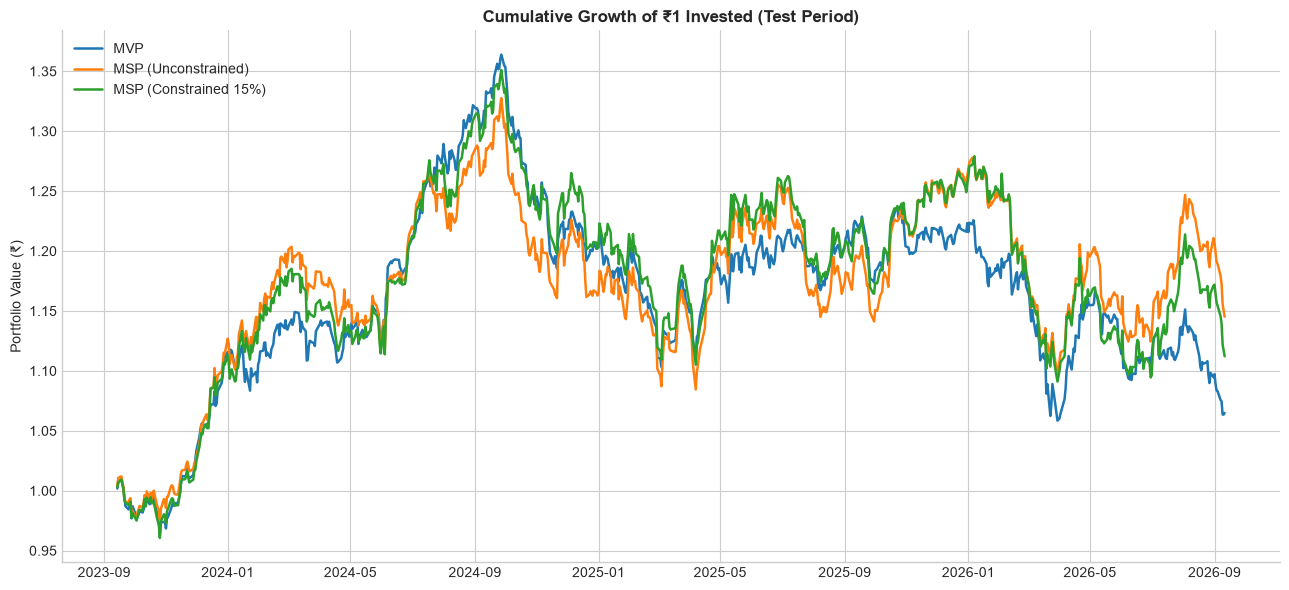

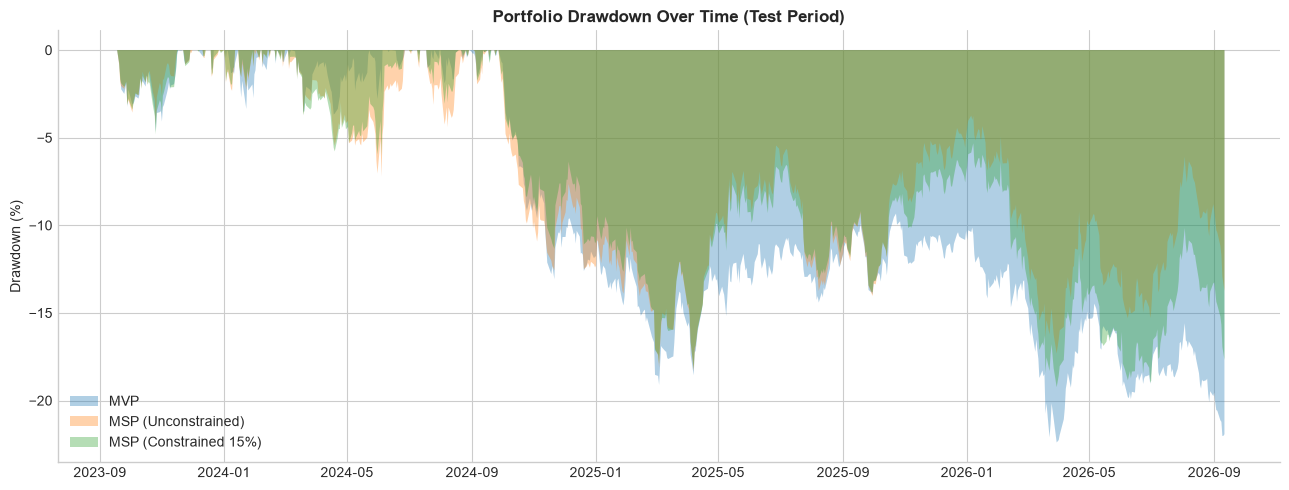

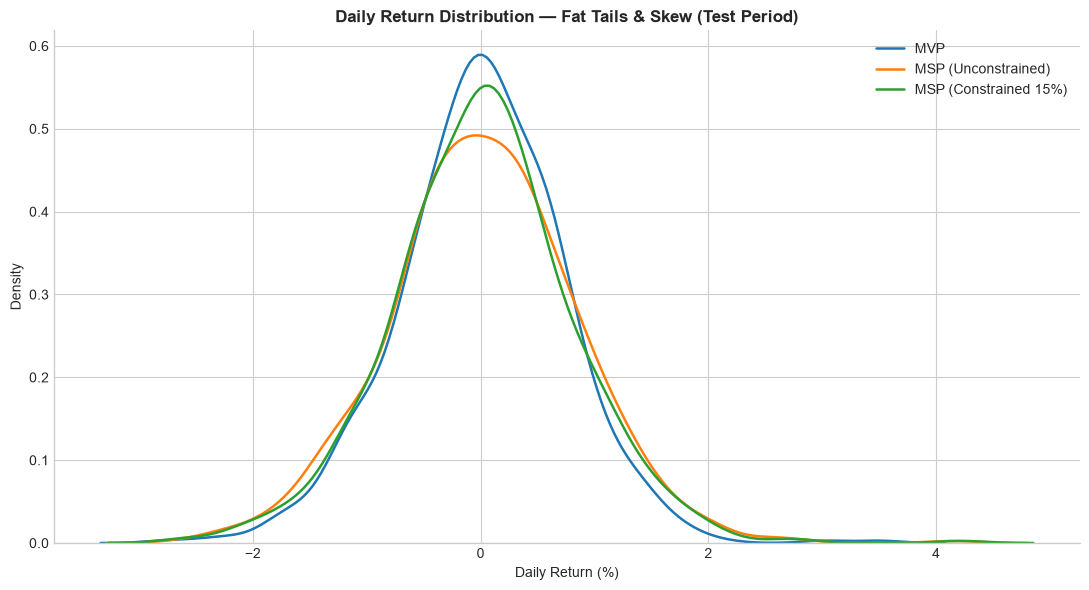

In [14]:
# ============================================================
# STEP 5: Risk Analysis on Historical Portfolio Returns
# ============================================================
from scipy import stats

def portfolio_daily_returns(weights, returns_df):
    """Historical daily return series for a given weight vector."""
    return returns_df.dot(weights)

def max_drawdown(cum_returns):
    """Max drawdown from a cumulative return series (starts at 1.0)."""
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    return drawdown.min(), drawdown

def var_cvar(returns, confidence=0.95):
    """Historical VaR and CVaR (Expected Shortfall) at given confidence level."""
    var = -np.percentile(returns, (1 - confidence) * 100)
    cvar = -returns[returns <= -var].mean()
    return var, cvar

def sharpe_sortino_calmar(returns, mdd, rf=RISK_FREE_RATE, trading_days=252):
    ann_ret = returns.mean() * trading_days
    ann_vol = returns.std() * np.sqrt(trading_days)
    sharpe = (ann_ret - rf) / ann_vol
    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(trading_days)
    sortino = (ann_ret - rf) / downside_vol if downside_vol > 0 else np.nan
    calmar = ann_ret / abs(mdd) if mdd != 0 else np.nan
    return ann_ret, ann_vol, sharpe, sortino, calmar

# ---- Build historical daily return series for each portfolio (TEST PERIOD ONLY) ----
portfolios = {
    'MVP': mvp_weights,
    'MSP (Unconstrained)': msp_weights,
    'MSP (Constrained 15%)': msp_c_weights
}

risk_results = {}
cum_returns_dict = {}
drawdown_dict = {}

for name, w in portfolios.items():
    port_ret = portfolio_daily_returns(w, test_returns)
    cum_ret = (1 + port_ret).cumprod()
    mdd, dd_series = max_drawdown(cum_ret)
    var95, cvar95 = var_cvar(port_ret, 0.95)
    var99, cvar99 = var_cvar(port_ret, 0.99)
    skew = stats.skew(port_ret)
    kurt = stats.kurtosis(port_ret)  # excess kurtosis (0 = normal)
    ann_ret, ann_vol, sharpe, sortino, calmar = sharpe_sortino_calmar(port_ret, mdd)

    risk_results[name] = {
        'Ann_Return_%': ann_ret * 100,
        'Ann_Volatility_%': ann_vol * 100,
        'Sharpe': sharpe,
        'Sortino': sortino,
        'Calmar': calmar,
        'Max_Drawdown_%': mdd * 100,
        'Daily_VaR_95_%': var95 * 100,
        'Daily_CVaR_95_%': cvar95 * 100,
        'Daily_VaR_99_%': var99 * 100,
        'Daily_CVaR_99_%': cvar99 * 100,
        'Skewness': skew,
        'Excess_Kurtosis': kurt
    }
    cum_returns_dict[name] = cum_ret
    drawdown_dict[name] = dd_series

risk_df = pd.DataFrame(risk_results).T
print("=== Risk & Performance Summary (Test Period, Out-of-Sample) ===")
print(risk_df.round(3))

# ---- Plot 1: Cumulative returns ----
fig, ax = plt.subplots(figsize=(13, 6))
for name, cum_ret in cum_returns_dict.items():
    ax.plot(cum_ret.index, cum_ret.values, label=name, linewidth=1.8)
ax.set_title('Cumulative Growth of ₹1 Invested (Test Period)', fontweight='bold')
ax.set_ylabel('Portfolio Value (₹)')
ax.legend(loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('reports/figures/05_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot 2: Drawdown ----
fig, ax = plt.subplots(figsize=(13, 5))
for name, dd in drawdown_dict.items():
    ax.fill_between(dd.index, dd.values * 100, 0, alpha=0.35, label=name)
ax.set_title('Portfolio Drawdown Over Time (Test Period)', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend(loc='lower left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('reports/figures/05_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot 3: Return distribution (fat tails / skew check) ----
fig, ax = plt.subplots(figsize=(11, 6))
for name, w in portfolios.items():
    port_ret = portfolio_daily_returns(w, test_returns)
    sns.kdeplot(port_ret * 100, label=name, ax=ax, linewidth=1.8)
ax.set_title('Daily Return Distribution — Fat Tails & Skew (Test Period)', fontweight='bold')
ax.set_xlabel('Daily Return (%)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('reports/figures/05_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

=== Backtest Results (Test Period, Monthly Rebalancing + Transaction Costs) ===
                                  Final_Value_(₹100_start)  Ann_Return_%  \
MVP - Rebalanced                                  106.0000        2.6400   
MSP (Unconstrained) - Rebalanced                  114.2200        5.3800   
MSP (Constrained) - Rebalanced                    111.1700        4.4000   
MSP (Constrained) - Buy & Hold                    108.9700        3.7000   

                                  Ann_Volatility_%  Sharpe  Max_Drawdown_%  \
MVP - Rebalanced                           11.4600 -0.3400        -22.3800   
MSP (Unconstrained) - Rebalanced           13.0900 -0.0900        -18.3200   
MSP (Constrained) - Rebalanced             12.6300 -0.1700        -19.0500   
MSP (Constrained) - Buy & Hold             12.5000 -0.2200        -19.6400   

                                  Total_Txn_Cost_(₹)  
MVP - Rebalanced                              0.1700  
MSP (Unconstrained) - Rebalanced      

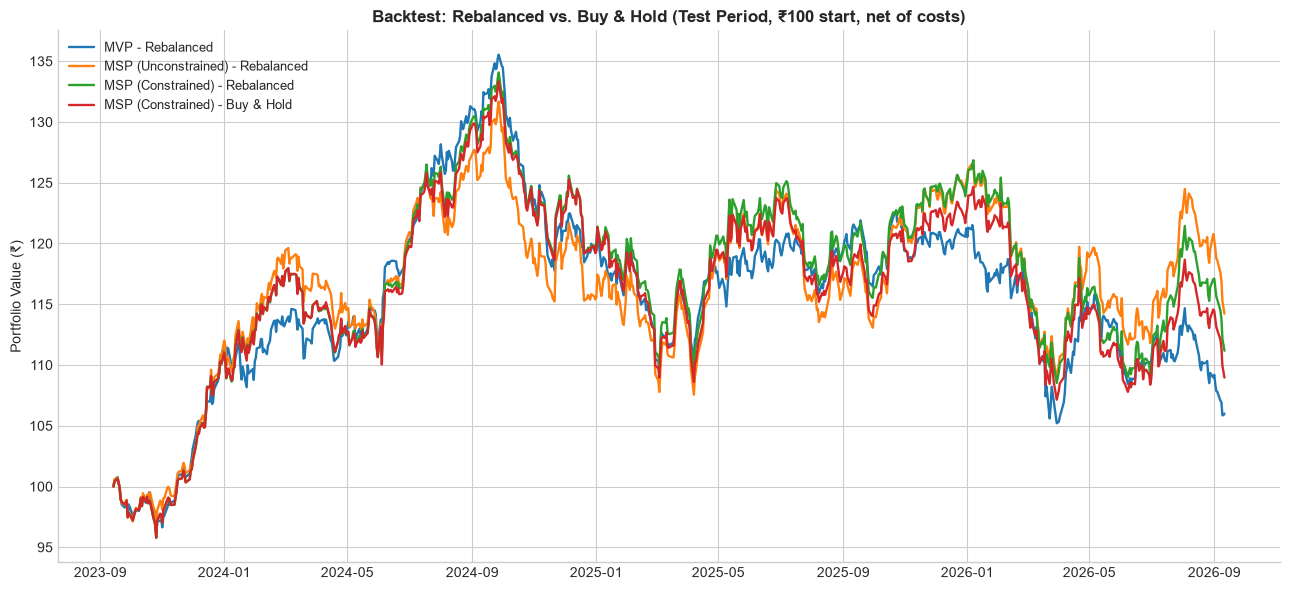

In [15]:
# ============================================================
# STEP 6: Backtest — Monthly Rebalancing + Transaction Costs
# ============================================================

TXN_COST = 0.001  # 0.1% per unit of turnover (blended brokerage + STT + slippage)

def backtest_portfolio(prices, target_weights, rebalance=True, txn_cost=TXN_COST, initial_capital=100):
    """
    Simulates holding a portfolio that drifts with daily prices, and — if
    rebalance=True — is reset to target_weights at each month-end, paying
    transaction costs proportional to turnover.
    """
    tickers = prices.columns
    dates = prices.index
    daily_ret = prices.pct_change().fillna(0)

    month_of_date = pd.Series(dates, index=dates).dt.to_period('M')
    rebal_flags = month_of_date != month_of_date.shift(1)  # True on first day of new month (not last day of old)
    rebal_flags.iloc[0] = False  # don't rebalance on day 0, already at target

    holdings_value = pd.Series(target_weights * initial_capital, index=tickers)
    portfolio_values = []
    total_cost_paid = 0.0

    for i, date in enumerate(dates):
        if i > 0:
            holdings_value = holdings_value * (1 + daily_ret.loc[date])

        current_total = holdings_value.sum()

        if rebalance and rebal_flags.loc[date] and i > 0:
            target_value = target_weights * current_total
            turnover = np.abs(target_value - holdings_value.values).sum() / current_total
            # turnover = sum of |buy| + |sell| legs (not halved) — cost applied to full traded value
            cost = turnover * txn_cost * current_total
            total_cost_paid += cost
            current_total -= cost
            holdings_value = pd.Series(target_weights * current_total, index=tickers)

        portfolio_values.append(holdings_value.sum())

    portfolio_series = pd.Series(portfolio_values, index=dates)
    return portfolio_series, total_cost_paid

# ---- Run backtests: rebalanced (with costs) vs buy & hold (no rebalancing) — TEST PERIOD ONLY ----
backtest_configs = {
    'MVP - Rebalanced': (mvp_weights, True),
    'MSP (Unconstrained) - Rebalanced': (msp_weights, True),
    'MSP (Constrained) - Rebalanced': (msp_c_weights, True),
    'MSP (Constrained) - Buy & Hold': (msp_c_weights, False),
}

backtest_results = {}
backtest_series = {}

for name, (w, rebal) in backtest_configs.items():
    series, cost = backtest_portfolio(test_prices, w, rebalance=rebal, txn_cost=TXN_COST)
    port_ret = series.pct_change().dropna()
    cum = series / series.iloc[0]
    mdd, _ = max_drawdown(cum)
    ann_ret, ann_vol, sharpe, sortino, calmar = sharpe_sortino_calmar(port_ret, mdd)

    backtest_results[name] = {
        'Final_Value_(₹100_start)': series.iloc[-1],
        'Ann_Return_%': ann_ret * 100,
        'Ann_Volatility_%': ann_vol * 100,
        'Sharpe': sharpe,
        'Max_Drawdown_%': mdd * 100,
        'Total_Txn_Cost_(₹)': cost
    }
    backtest_series[name] = series

backtest_df = pd.DataFrame(backtest_results).T
print("=== Backtest Results (Test Period, Monthly Rebalancing + Transaction Costs) ===")
print(backtest_df.round(2))

# ---- Also compare: MSP constrained rebalanced WITH vs WITHOUT costs, to isolate cost impact ----
series_no_cost, _ = backtest_portfolio(test_prices, msp_c_weights, rebalance=True, txn_cost=0.0)
final_no_cost = series_no_cost.iloc[-1]
final_with_cost = backtest_series['MSP (Constrained) - Rebalanced'].iloc[-1]
print(f"\nCost drag on Constrained MSP: ₹{final_no_cost:.2f} (no cost) → ₹{final_with_cost:.2f} (with cost) "
      f"= {(final_no_cost - final_with_cost)/final_no_cost*100:.2f}% eroded by transaction costs")

# ---- Plot: backtest comparison ----
fig, ax = plt.subplots(figsize=(13, 6))
for name, series in backtest_series.items():
    ax.plot(series.index, series.values, label=name, linewidth=1.7)
ax.set_title('Backtest: Rebalanced vs. Buy & Hold (Test Period, ₹100 start, net of costs)', fontweight='bold')
ax.set_ylabel('Portfolio Value (₹)')
ax.legend(loc='upper left', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('reports/figures/06_backtest_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

=== Test-Period Comparison: Optimized Portfolios vs. Equal-Weight vs. Nifty 50 ===
                                  Final_Value_(₹100_start)  Ann_Return_%  \
Equal-Weight (1/N)                                122.2400        7.5300   
Nifty 50 (Buy & Hold)                             116.3900        6.0400   
MVP - Rebalanced                                  106.0000        2.6400   
MSP (Unconstrained) - Rebalanced                  114.2200        5.3800   
MSP (Constrained) - Rebalanced                    111.1700        4.4000   

                                  Ann_Volatility_%  Sharpe  Max_Drawdown_%  
Equal-Weight (1/N)                         11.8700  0.0900        -17.1900  
Nifty 50 (Buy & Hold)                      13.2100 -0.0400        -15.7700  
MVP - Rebalanced                           11.4600 -0.3400        -22.3800  
MSP (Unconstrained) - Rebalanced           13.0900 -0.0900        -18.3200  
MSP (Constrained) - Rebalanced             12.6300 -0.1700        -19.0500 

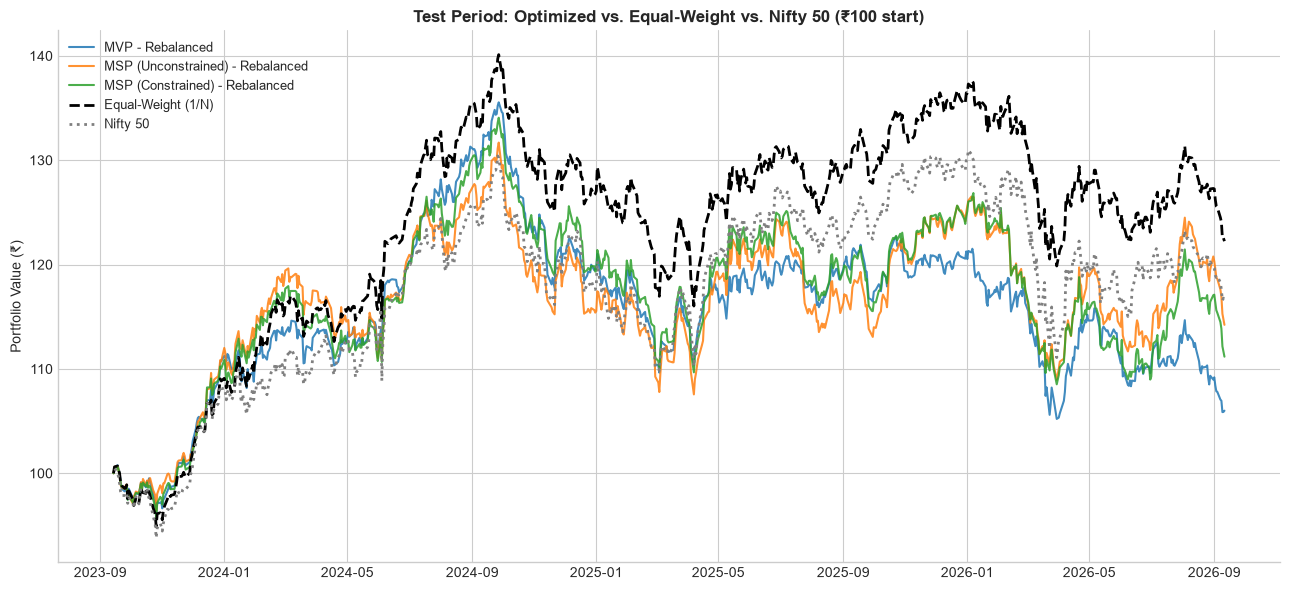

In [18]:
# ============================================================
# STEP 6.5: Benchmark Comparison — Equal-Weight Baseline & Nifty 50
# ============================================================

# ---- Equal-weight baseline (no optimization, just 1/N) ----
equal_weights = np.array([1/n_assets] * n_assets)

# ---- Download Nifty 50 index for the same test period ----
nifty_raw = yf.download('^NSEI', start=test_prices.index.min(), end=test_prices.index.max() + timedelta(days=1),
                         auto_adjust=True, progress=False)
nifty_prices = nifty_raw['Close'].reindex(test_prices.index, method='ffill').dropna().squeeze()

# align test_prices to nifty's actual trading days (in case of holiday mismatches)
common_dates = test_prices.index.intersection(nifty_prices.index)
nifty_prices = nifty_prices.loc[common_dates]

nifty_ret = nifty_prices.pct_change().dropna()
nifty_cum = (1 + nifty_ret).cumprod()
nifty_mdd, _ = max_drawdown(nifty_cum)
nifty_ann_ret, nifty_ann_vol, nifty_sharpe, nifty_sortino, nifty_calmar = sharpe_sortino_calmar(
    nifty_ret.squeeze(), nifty_mdd
)

# ---- Backtest equal-weight the same way as the optimized portfolios ----
eq_series, eq_cost = backtest_portfolio(test_prices, equal_weights, rebalance=True, txn_cost=TXN_COST)
eq_port_ret = eq_series.pct_change().dropna()
eq_cum = eq_series / eq_series.iloc[0]
eq_mdd, _ = max_drawdown(eq_cum)
eq_ann_ret, eq_ann_vol, eq_sharpe, eq_sortino, eq_calmar = sharpe_sortino_calmar(eq_port_ret, eq_mdd)

# ---- Build comparison table ----
benchmark_results = {
    'Equal-Weight (1/N)': {
        'Final_Value_(₹100_start)': eq_series.iloc[-1],
        'Ann_Return_%': eq_ann_ret * 100,
        'Ann_Volatility_%': eq_ann_vol * 100,
        'Sharpe': eq_sharpe,
        'Max_Drawdown_%': eq_mdd * 100,
    },
    'Nifty 50 (Buy & Hold)': {
        'Final_Value_(₹100_start)': 100 * nifty_cum.iloc[-1],
        'Ann_Return_%': nifty_ann_ret * 100,
        'Ann_Volatility_%': nifty_ann_vol * 100,
        'Sharpe': nifty_sharpe,
        'Max_Drawdown_%': nifty_mdd * 100,
    }
}

# pull in the already-computed optimized portfolios for side-by-side comparison
for name in ['MVP - Rebalanced', 'MSP (Unconstrained) - Rebalanced', 'MSP (Constrained) - Rebalanced']:
    benchmark_results[name] = {
        'Final_Value_(₹100_start)': backtest_df.loc[name, 'Final_Value_(₹100_start)'],
        'Ann_Return_%': backtest_df.loc[name, 'Ann_Return_%'],
        'Ann_Volatility_%': backtest_df.loc[name, 'Ann_Volatility_%'],
        'Sharpe': backtest_df.loc[name, 'Sharpe'],
        'Max_Drawdown_%': backtest_df.loc[name, 'Max_Drawdown_%'],
    }

benchmark_df = pd.DataFrame(benchmark_results).T
print("=== Test-Period Comparison: Optimized Portfolios vs. Equal-Weight vs. Nifty 50 ===")
print(benchmark_df.round(2))

# ---- Plot: all series together ----
fig, ax = plt.subplots(figsize=(13, 6))
for name, series in backtest_series.items():
    if 'Rebalanced' in name:
        ax.plot(series.index, series.values, label=name, linewidth=1.5, alpha=0.85)
ax.plot(eq_series.index, eq_series.values, label='Equal-Weight (1/N)', linewidth=2, color='black', linestyle='--')
ax.plot(nifty_cum.index, 100 * nifty_cum.values, label='Nifty 50', linewidth=2, color='gray', linestyle=':')
ax.set_title('Test Period: Optimized vs. Equal-Weight vs. Nifty 50 (₹100 start)', fontweight='bold')
ax.set_ylabel('Portfolio Value (₹)')
ax.legend(loc='upper left', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('reports/figures/06b_benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

=== FINAL SUMMARY: Expected (Mean-Variance) vs Historical vs Backtested ===
                       Expected_Return_%  Expected_Sharpe  \
Strategy                                                    
MVP                              17.1800           0.7800   
MSP (Unconstrained)              23.6100           1.0200   
MSP (Constrained 15%)            22.5400           1.0000   

                       Historical_Return_%  Historical_Sharpe  Max_Drawdown_%  \
Strategy                                                                        
MVP                                 2.7900            -0.3200        -22.3900   
MSP (Unconstrained)                 5.4600            -0.0800        -18.3100   
MSP (Constrained 15%)               4.4100            -0.1700        -19.2400   

                       Backtest_Return_%  Backtest_Sharpe  
Strategy                                                   
MVP                               2.6400          -0.3400  
MSP (Unconstrained)             

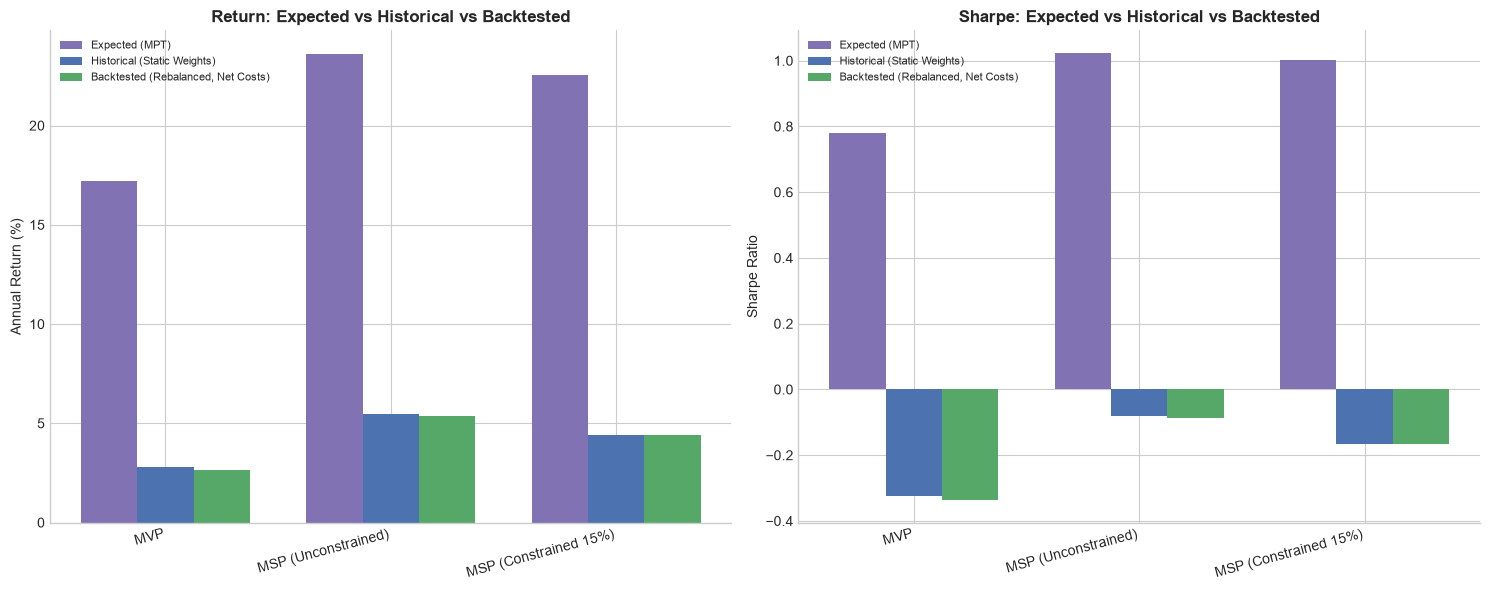


Saved: portfolio_weights.csv, risk_metrics.csv, backtest_results.csv, final_summary.csv


In [16]:
# ============================================================
# STEP 7: Consolidated Results Summary (Expected vs. Realized)
# ============================================================

summary = pd.DataFrame({
    'Strategy': ['MVP', 'MSP (Unconstrained)', 'MSP (Constrained 15%)'],
    'Expected_Return_%': [mvp_ret*100, msp_ret*100, msp_c_ret*100],
    'Expected_Sharpe': [mvp_sharpe, msp_sharpe, msp_c_sharpe],
    'Historical_Return_%': [risk_df.loc['MVP','Ann_Return_%'],
                             risk_df.loc['MSP (Unconstrained)','Ann_Return_%'],
                             risk_df.loc['MSP (Constrained 15%)','Ann_Return_%']],
    'Historical_Sharpe': [risk_df.loc['MVP','Sharpe'],
                           risk_df.loc['MSP (Unconstrained)','Sharpe'],
                           risk_df.loc['MSP (Constrained 15%)','Sharpe']],
    'Max_Drawdown_%': [risk_df.loc['MVP','Max_Drawdown_%'],
                        risk_df.loc['MSP (Unconstrained)','Max_Drawdown_%'],
                        risk_df.loc['MSP (Constrained 15%)','Max_Drawdown_%']],
    'Backtest_Return_%': [backtest_df.loc['MVP - Rebalanced','Ann_Return_%'],
                           backtest_df.loc['MSP (Unconstrained) - Rebalanced','Ann_Return_%'],
                           backtest_df.loc['MSP (Constrained) - Rebalanced','Ann_Return_%']],
    'Backtest_Sharpe': [backtest_df.loc['MVP - Rebalanced','Sharpe'],
                         backtest_df.loc['MSP (Unconstrained) - Rebalanced','Sharpe'],
                         backtest_df.loc['MSP (Constrained) - Rebalanced','Sharpe']],
}).set_index('Strategy')

print("=== FINAL SUMMARY: Expected (Mean-Variance) vs Historical vs Backtested ===")
print(summary.round(2))

# ---- Summary bar chart ----
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x = np.arange(len(summary))
width = 0.25
axes[0].bar(x - width, summary['Expected_Return_%'], width, label='Expected (MPT)', color='#8172B3')
axes[0].bar(x, summary['Historical_Return_%'], width, label='Historical (Static Weights)', color='#4C72B0')
axes[0].bar(x + width, summary['Backtest_Return_%'], width, label='Backtested (Rebalanced, Net Costs)', color='#55A868')
axes[0].set_xticks(x)
axes[0].set_xticklabels(summary.index, rotation=15, ha='right')
axes[0].set_ylabel('Annual Return (%)')
axes[0].set_title('Return: Expected vs Historical vs Backtested', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].bar(x - width, summary['Expected_Sharpe'], width, label='Expected (MPT)', color='#8172B3')
axes[1].bar(x, summary['Historical_Sharpe'], width, label='Historical (Static Weights)', color='#4C72B0')
axes[1].bar(x + width, summary['Backtest_Sharpe'], width, label='Backtested (Rebalanced, Net Costs)', color='#55A868')
axes[1].set_xticks(x)
axes[1].set_xticklabels(summary.index, rotation=15, ha='right')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].set_title('Sharpe: Expected vs Historical vs Backtested', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('reports/figures/07_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Save all key tables to CSV for the repo ----
import os
os.makedirs('reports', exist_ok=True)
weights_df.to_csv('reports/portfolio_weights.csv')
risk_df.to_csv('reports/risk_metrics.csv')
backtest_df.to_csv('reports/backtest_results.csv')
summary.to_csv('reports/final_summary.csv')
print("\nSaved: portfolio_weights.csv, risk_metrics.csv, backtest_results.csv, final_summary.csv")